**Read README.md first.**

author: Xu Chen, 2021/12/4， xuchen21@mails.ucas.ac.cn

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
from hifast.ripple.util import *
from hifast.ripple.sw_fft import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
# 这里是已经去过基线的-bld.hdf5文件
subname = '/data/inspur_disk01/userdir/jyj/FAST/jingyj/hifast/example_1/process/data_S/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-flux-bld.hdf5'
sub = h5py.File(subname,'r')
subs = sub['S']

In [3]:
# 这里是包含rfi标记的-bld-rfi.hdf5文件
rfiname = '/data/inspur_disk01/userdir/jyj/FAST/jingyj/hifast/example_1/process/data_S/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-flux-bld-rfi.hdf5'
rfi = h5py.File(rfiname,'r')
rfis = rfi['S']

# example polar yy

以偏振yy为例去除驻波

In [4]:
subs.keys()

<KeysViewHDF5 ['Tcal', 'dec', 'flux', 'freq', 'is_delay', 'is_extrapo', 'is_on', 'mjd', 'next_to_cal', 'ra']>

In [4]:
data = subs['flux'][1,:,:] # yy 偏振
freq = subs['freq'][:]
is_on = subs['is_on'][:]
is_rfi = rfis['is_rfi'][:]

In [5]:
data.shape,freq.shape

((6057, 3277), (3277,))

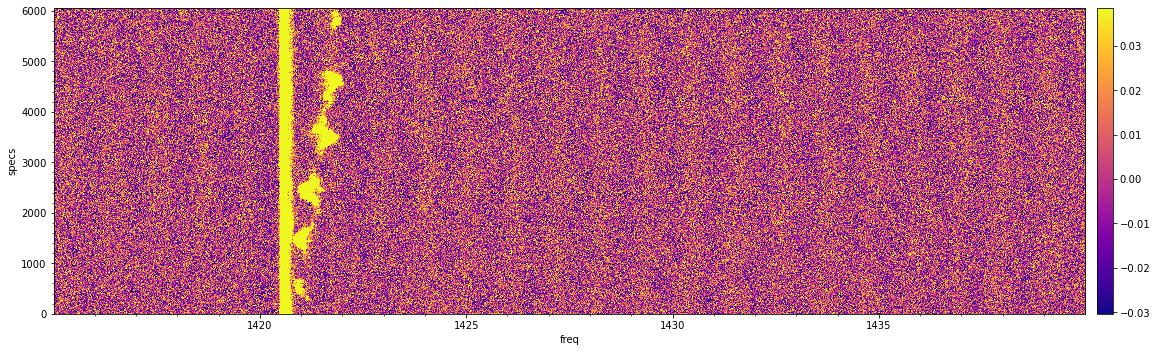

In [7]:
plot_waterfall(subs,data,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma')

# RMS

目前rms是手动指定选一个没有信号和干扰范围。用于判断大的信号。例如```--rms_frange 1425 1435```

In [5]:
import mpl_interactions.ipyplot as iplt

In [6]:
%matplotlib ipympl
spec = deepcopy(data[0,:])
def test_gauss(freq,sigma):
    from hifast.utils.misc import smooth1d
    sm = smooth1d(spec,method='gaussian',sigma=sigma)
    return sm

fig,ax = plt.subplots(figsize=(10,2))
iplt.plot(freq,spec,label = 'ori')
controls = iplt.plot(freq, test_gauss,  sigma=np.arange(2, 20, 1),xlim = [1425,1435],
                     ylim=[-.1,.1],color = 'C1',label='smooth')
iplt.title("sigma is {sigma:.2f}", controls=controls['sigma'])
plt.legend()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

(如果发现了交互没反应，重启内核并跳过前面画瀑布图即可

# MW range
有MW的区域，下面会被强制替代为驻波。例如下图的判断，如果输入了```--mw_frange 1420.3,1420.8```，那么MW将都被替代。注意过长将影响对驻波估计的效果，所以也可以不输入(None)

(1420.0, 1423.0)

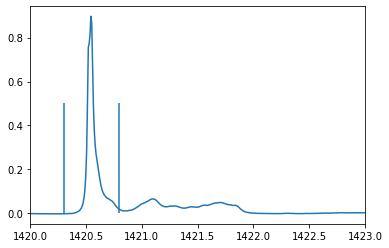

In [8]:
mw_frange = (1420.3,1420.8)
%matplotlib inline
plt.plot(freq,np.mean(data,axis = 0))
plt.vlines(mw_frange,ymin=0,ymax = .5)
plt.xlim(1420.0,1423)

接下来，考虑离散fourier变换的两端会拟合效果很差，可以在下一步切去两端或者在两端延长(未整合，但是测试过)，使得最终的结果保持良好的去驻波效果。这里不再演示

# Replace RFI or strong sources

这里'near ripple'使用高流量处附近的驻波替代源或RFI。例如
* `--times_lower_thr`:大于RMS这么多倍的会被替代
* `--rfi_width_lim`: 要替换的rfi/源，频率上的宽度应该大于一阈值(通道数)
* `--ext_sec`: (接上面的)并向两边扩展通道数
* `--ext_freq`: 先扩展边缘(MHz)，再寻找强流量两边的最低点，先使用左/右边的一段更干净一点的代替强流量处，默认1.3即可


In [7]:
%matplotlib ipympl
def test_replace(freq,rms_sigma=6,rms_frange=[1425,1435],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    usespec,rep_area = [], []
    fdelta = freq[1]-freq[0] 
    N = len(freq)
    ext = int(np.around(ext_freq / fdelta))
    
    from hifast.ripple.markRFI import real_rms,rms,get_startend
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)
    thr = RMS * times_lower_thr
    from hifast.utils.misc import smooth1d
    sm = smooth1d(spec,method='gaussian',sigma=rms_sigma)
    low_use = (np.abs(sm) > thr * .5) | is_rfi[tn]

    start,end = get_startend(low_use,rfi_width_lim, ext_sec)
    from hifast.ripple.sw_fft import replace_spec
    spec_ = deepcopy(spec)
    newspec = deepcopy(spec)
    newspec_ = deepcopy(spec)
    MAX = np.max(spec)
    include = mw_use #| is_rfi[tn]
    if np.sum(include) > 0:
        spec_[include] = MAX * 20       
    
    newspec,usespec,rep_area = replace_spec(tn,spec_,freq,low_use,rfi_width_lim, ext_sec, 
                                   ext, RMS, MAX,test=True,smooth = sm)

    strange = np.where(np.abs(newspec) > times_lower_thr * RMS)[0]
    newspec[strange] = np.random.normal(scale=RMS, size=len(strange))

    return rep_area,usespec,newspec

def test_replace_rep(freq,rms_sigma=6,rms_frange=[1425,1435],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    rep_area,usespec,newspec = test_replace(freq,rms_sigma,rms_frange,times_lower_thr,rfi_width_lim, ext_sec,ext_freq)
    return rep_area * .07
def test_replace_use(freq,rms_sigma=6,rms_frange=[1425,1435],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    rep_area,usespec,newspec = test_replace(freq,rms_sigma,rms_frange,times_lower_thr,rfi_width_lim, ext_sec,ext_freq)
    return usespec * .05
def test_replace_new(freq,rms_sigma=6,rms_frange=[1425,1435],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    rep_area,usespec,newspec = test_replace(freq,rms_sigma,rms_frange,times_lower_thr,rfi_width_lim, ext_sec,ext_freq)
    return newspec - .1

def test_replace_thr(freq,rms_sigma=6,rms_frange=[1425,1435],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    from hifast.ripple.markRFI import real_rms,rms
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)

    thr_lower = RMS*times_lower_thr
    thr = np.full(len(freq),thr_lower)
    return thr
def test_replace_thr2(freq,rms_sigma=6,rms_frange=[1425,1435],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    from hifast.ripple.markRFI import real_rms,rms
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)

    thr_lower = RMS*times_lower_thr
    thr = np.full(len(freq),thr_lower)
    return thr/2

通过单条谱线尝试参数，划分被replace的范围.之前已经确定了rms_sigma=6,rms_frange=[1390,1400]，这里测试,times_lower_thr,rfi_width_lim, ext_sec，使得不要替代过多的噪声而速度变慢。

如果希望M33也全部被替代，可以给一个更大的`mw_frange`

(1420.0, 1423.0)

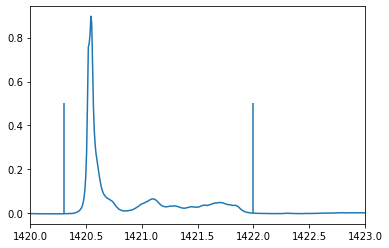

In [8]:
mw_frange = (1420.3,1422)
%matplotlib inline
plt.plot(freq,np.mean(data,axis = 0))
plt.vlines(mw_frange,ymin=0,ymax = .5)
plt.xlim(1420.0,1423)

1. 如果输入`mw_frange`参数，可能出现**MW和M33连同中间的一段驻波都被替换了**，与原始谱线不符(中间的一段驻波有时可以不替换)，下面是输入后`mw_frange`都替换的情形：
```
times_lower_thr = 4
rfi_width_lim = 10 
ext_sec = 2
```

In [9]:
%matplotlib ipympl
mw_use = (freq > mw_frange[0])&(freq < mw_frange[1])
tn = 6000
xlim = [1415,1430]
ylim = [-.15,.1]

#spec = deepcopy(np.mean(data[tn-5:tn+5,:],axis = 0))
spec = deepcopy(data[tn])
fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(111)
iplt.plot(freq,spec,label='original',alpha = .5)
plt.plot(freq,is_rfi[tn]*.08,'k',alpha=.5,label='is_rfi')
from hifast.utils.misc import smooth1d
sm = smooth1d(spec,method='gaussian',sigma=6)
ax.plot(freq,sm,'m',alpha=.5,label='smooth')
#iplt.plot(freq,mw_use*1.5,label='mw',alpha = .5)
controls = iplt.plot(freq, test_replace_rep,times_lower_thr=np.arange(1.,10,.25),
                     rfi_width_lim=np.arange(3,20,1).astype(int), 
                     ext_sec=np.arange(1,20,1).astype(int),
                     ext_freq=np.arange(1.3,5,0.1),xlim=xlim,ylim=ylim,label='rep area')
iplt.plot(freq,test_replace_use,controls = controls,
                     alpha=.8,xlim=xlim,ylim=ylim,label = 'copy from')
iplt.plot(freq,test_replace_new,controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'after replace')
iplt.plot(freq,test_replace_thr,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
iplt.plot(freq,test_replace_thr2,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr/2')
ax.grid();ax.legend(loc='right')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

阈值：

thr用于剔除异常RFI

thr/2用于在平滑后的谱线决定替换哪些区域

2. 不输入`mw_frange`参数，又要注意，**M33比较弱时，难以达到下图第二条较低的虚线阈值从而不会被替换**。这样直接FFT是可能有流量损失的。可以通过比较低的阈值或者如果要求M33全部被替换，回到上一种方法。
```
times_lower_thr = 2.5
rfi_width_lim = 10 
ext_sec = 2
```

In [10]:
mw_use = np.full(freq.shape,False)
tn = 6000
xlim = [1415,1430]
ylim = [-.15,.1]

#spec = deepcopy(np.mean(data[tn-5:tn+5,:],axis = 0))
spec = deepcopy(data[tn])
fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(111)
iplt.plot(freq,spec,label='original',alpha = .5)
plt.plot(freq,is_rfi[tn]*.08,'k',alpha=.5,label='is_rfi')
from hifast.utils.misc import smooth1d
sm = smooth1d(spec,method='gaussian',sigma=6)
ax.plot(freq,sm,'m',alpha=.5,label='smooth')
#iplt.plot(freq,mw_use*1.5,label='mw',alpha = .5)
controls = iplt.plot(freq, test_replace_rep,times_lower_thr=np.arange(1.,10,.25),
                     rfi_width_lim=np.arange(3,20,1).astype(int), 
                     ext_sec=np.arange(1,20,1).astype(int),
                     ext_freq=np.arange(1.3,5,0.1),xlim=xlim,ylim=ylim,label='rep area')
iplt.plot(freq,test_replace_use,controls = controls,
                     alpha=.8,xlim=xlim,ylim=ylim,label = 'copy from')
iplt.plot(freq,test_replace_new,controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'after replace')
iplt.plot(freq,test_replace_thr,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
iplt.plot(freq,test_replace_thr2,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr/2')
ax.grid();ax.legend(loc='right')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

这里发现重叠，其实是分段替代了

所以我推荐第二种方法，尽管在星系HI峰的边缘驻波拟合很难

## replace
前面确定好了参数，现在处理所有谱线

In [11]:
%matplotlib inline
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1425,1435]
rep_args['times_lower_thr'] = 2.5
rep_args['rfi_width_lim'] = 10
rep_args['ext_sec'] = 2
rep_args['ext_freq'] = 1.3

In [12]:
data_rep = replace_rfi(data,freq,time_rfi =is_rfi, method='near_ripple',mw_frange= None, **rep_args)

INFO: Replace RFI with near_ripple method ... [hifast.ripple.sw_fft]
INFO: tn = 2113 has a ValueError, will replace with noise [hifast.ripple.sw_fft]


替代后瀑布图的效果

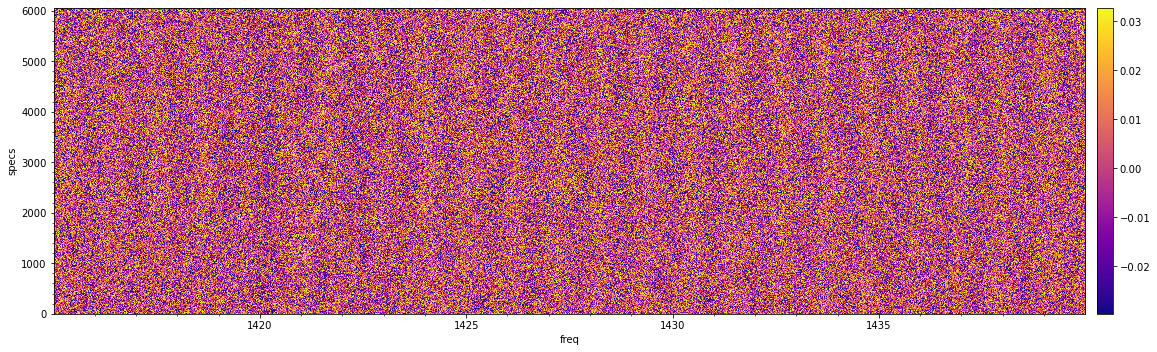

In [13]:
plot_waterfall(subs,data = data_rep,per_vmin_max=.90,cmap='plasma',figsize=(18,5))

# FFT remove 1MHz ripples
* ```--sw_base```: 去除傅里叶空间的常数成分。如果基线整体偏离0, 此参数设为True可缓解。
* ```--sw_periods```: 去除的驻波成分。后可接多个字符。默认为```1mhz 2mhz 0_04mhz```. 字符与对应的驻波周期为：
   * 字符: 驻波周期
   * 1mhz: 1.08mhz
   * 2mhz: 1.92mhz
   * 0_04mhz: 0.039 mhz

* ```--check_2mhz```: 若为True，如果输入Beam 6文件，将在```--sw_periods```中添加'2mhz', 如果输入的不是Beam 6文件，则删除'2mhz'(如果存在)。因为'2mhz'驻波目前只存在于Beam 6 中。
* ```--amp_thr_mean_factor```: 傅里叶空间的平均振幅大于阈值的模，会被识别为已知的几种驻波。这里输入的是中值的倍数
* ```--amp_thr_solo_factor```: 傅里叶空间的每一谱线的振幅大于阈值，会被选中为驻波一部分被去除。这里输入的是中值的倍数
* ```--chan_wide```: 距离驻波的模的中心左右各(2 * chann - 1)个通道数的模，作为驻波的一部分被选中. 用于'1mhz'和'2mhz'的驻波。默认为5
* ```--chan_narr```: 同上，窄一些的. 用于'0_04mhz'的驻波。默认为3
* ```--choose_method```: 选择傅里叶空间中哪些模作为驻波的方法，'all'或者'interpolate'. 默认为'all'.


然后对data_rep进行FFT

In [14]:
from hifast.ripple.sw_fft import *
sw = SW_FFT(data_rep, freq, 10)
sw.do_fft()

/home/xuc/.local/lib/python3.9/site-packages/hifast/ripple/sw_fft.py:316: RuntimeWarning: divide by zero encountered in true_divide
  self.period = 1/self.x


In [15]:
x = sw.x
amp_data = sw.amp
amp_mean = np.nanmean(amp_data,axis=0)
amp_off = np.nanmean(amp_data[~is_on],axis=0)

Text(0.5, 24.0, 't [$\\mu s$]')

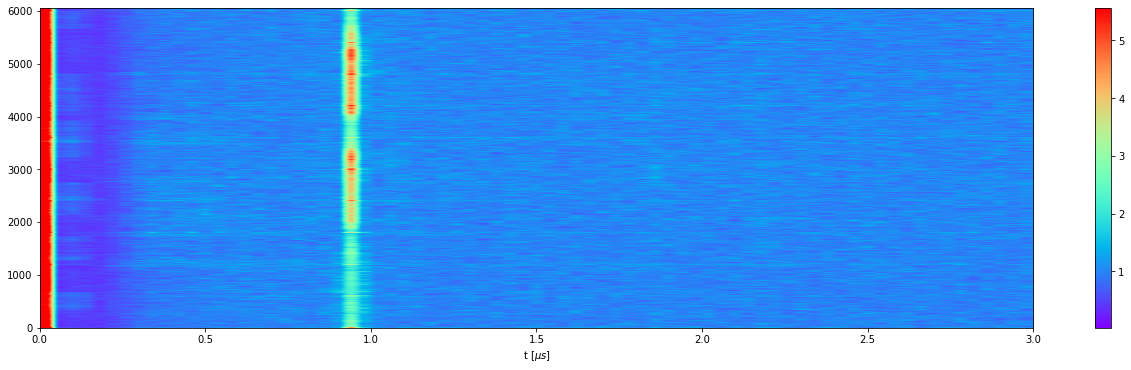

In [20]:
plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)
plt.xlabel("t [$\mu s$]")

这里先给出Fourier空间中取模的成分范围，1.0版本中单位是通道数(之后可能改成$\mu$s)，分宽和窄两种

In [16]:
chan_wide=3 # 这是半宽
chan_narr=1
cw = 2 * chan_wide - 1
cn = 2 * chan_narr - 1
print(f"all_chan_wide = {cw}, all_chan_narrow = {cn}")
is_excluded_mean = np.all(is_rfi, axis=1) # 严重RFI的谱线不会参与振幅平均

all_chan_wide = 5, all_chan_narrow = 1


内置的驻波种类，在$\mu$s轴上的大概范围，和选取的最大半通道数

In [17]:
sw_periods=['1mhz', '2mhz', '0_04mhz']
sw_conf = get_sw_conf(chan_wide, chan_narr)
sw_conf

{'1mhz': {'xlims': [[0.9, 0.95], [1.8, 1.9]], 'nchans': [3, 1]},
 '2mhz': {'xlims': [[0.5, 0.6]], 'nchans': [3]},
 '0_04mhz': {'xlims': [[25, 26]], 'nchans': [1]}}

通过平均所有振幅，决定该波束存在哪些驻波

In [18]:
def test_amp_mean(x,amp_thr_mean_factor):
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor=1.4,is_on=is_on,is_excluded_mean=is_excluded_mean)
    loc = []
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf[key]['xlims'])
        if np.sum(sw.bingo_list) > 1:
            for b in range(len(sw.bingo_list)):
                if sw.bingo_list[b]:
                    loc += [sw.loc_list[b],]
    if len(loc)>0: loc = np.hstack((loc))
    select = np.full(x.shape,np.nan)
    
    select[loc] = .5 # plot height
    print("---------------------------------")
    return select

def test_amp_mean_line(x,amp_thr_mean_factor):
    amp_thr = sw.amp_thr_mean
    return np.full(len(x),amp_thr)

改变这里的amp_thr_mean_factor，选择的驻波数量会变化(print的变化在log窗口里)

In [19]:
%matplotlib ipympl
ylim=[0,5]
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
iplt.plot(x,amp_mean,'.-', label = 'amp mean')
controls = iplt.plot(x,test_amp_mean,'^',amp_thr_mean_factor=np.arange(1,1.7,0.0015),
                     xlim=[-.01,2],ylim=ylim,label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                     alpha=.5,xlim=[-.01,2],ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

ax = fig.add_subplot(212) 
iplt.plot(x,amp_mean,'.-', label = 'amp mean')
iplt.plot(x,test_amp_mean,'^',controls=controls,
                     xlim=[25,26],ylim=ylim,label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                      alpha=.5,xlim=[25,26],ylim=ylim,label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08702 MHz,0.91994 mu s,locate in 23
find ripple 0.54351 MHz,1.83989 mu s,locate in 46
find ripple 1.66677 MHz,0.59996 mu s,locate in 15
find ripple 0.03968 MHz,25.19846 mu s,locate in 630
---------------------------------


VBox()

find ripple 1.08702 MHz,0.91994 mu s,locate in 23
find ripple 0.54351 MHz,1.83989 mu s,locate in 46
find ripple 1.66677 MHz,0.59996 mu s,locate in 15
find ripple 0.03968 MHz,25.19846 mu s,locate in 630
---------------------------------
find ripple 1.08702 MHz,0.91994 mu s,locate in 23
find ripple 0.54351 MHz,1.83989 mu s,locate in 46
find ripple 1.66677 MHz,0.59996 mu s,locate in 15
find ripple 0.03968 MHz,25.19846 mu s,locate in 630
---------------------------------
find ripple 1.08702 MHz,0.91994 mu s,locate in 23
find ripple 0.54351 MHz,1.83989 mu s,locate in 46
find ripple 1.66677 MHz,0.59996 mu s,locate in 15
find ripple 0.03968 MHz,25.19846 mu s,locate in 630
---------------------------------
find ripple 1.08702 MHz,0.91994 mu s,locate in 23
---------------------------------
find ripple 1.08702 MHz,0.91994 mu s,locate in 23
---------------------------------


从平均的fourier模，可以看出明显的几种驻波，1mhz和它的倍频0.54mhz

同理，决定单条谱线适用的阈值倍数amp_thr_factor和取模通道数，chan_wide,chan_narr。这里可视化测试off的谱线举例

In [20]:
def test_amp_solo(x,amp_thr_mean_factor,amp_thr_solo_factor,chan_wide,chan_narr):

    sw_conf1 = get_sw_conf(chan_wide, chan_narr)
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor,is_on=is_on,is_excluded_mean=is_excluded_mean)
    
    sw.is_use_sw_chan = np.full(x.shape,False)
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf1[key]['xlims'])
        sw.find_sw_chans(nchans=sw_conf1[key]['nchans'])
        is_use_sw_chan_amp = sw.is_use_sw_chan & (amp_data[tn] > sw.amp_thr_solo[tn])
    
    select = np.zeros_like(x)   
    select[is_use_sw_chan_amp] = amp_data[tn][is_use_sw_chan_amp] 
    print("---------------------------------")
    return select


def test_amp_solo_line(x,amp_thr_mean_factor,amp_thr_solo_factor,chan_wide,chan_narr):
    amp_thr = sw.amp_thr_solo[~is_on][tn][0]
    return np.full(len(x),amp_thr)

dx = x[1] - x[0]

In [21]:
tn = 0
%matplotlib ipympl
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
xlim=[-.01,2];ylim=[0,5]
iplt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
controls = iplt.plot(x,test_amp_solo,amp_thr_mean_factor=1.05,amp_thr_solo_factor=np.arange(1,3,0.02),
                     chan_wide=np.arange(1,9),chan_narr=np.arange(1,5),
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

xlim=[25,26]
ax = fig.add_subplot(212) 
iplt.plot(x,amp_data[tn], label = f'amp tn = {tn}')
iplt.plot(x,test_amp_solo,controls=controls,
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                      alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08702 MHz,0.91994 mu s,locate in 23
---------------------------------


VBox()

find ripple 1.08702 MHz,0.91994 mu s,locate in 23
---------------------------------


对于测试数据，我选择了以下参数.`choose_method`有选择所有模'all'和线性插值'interpolate'两种方式，可以分别尝试效果。

现在使用完整的函数进行测试

In [22]:
fft_args = {}
fft_args['amp_thr_mean_factor'] = 1.05
fft_args['amp_thr_solo_factor'] = 1.4
fft_args['chan_wide'] = 3
fft_args['chan_narr'] = 1
fft_args['choose_method'] = 'all'
fft_args['sw_periods'] = ['1mhz', '2mhz', '0_04mhz']
fft_args['sw_base'] = True
fft_args['is_on'] = is_on
fft_args['is_excluded_mean'] = np.all(is_rfi, axis=1)

In [23]:
sw_data = fit_sw_fft(data_rep, freq, nproc=10,  **fft_args)

/home/xuc/.local/lib/python3.9/site-packages/hifast/ripple/sw_fft.py:316: RuntimeWarning: divide by zero encountered in true_divide
  self.period = 1/self.x


find ripple 1.08702 MHz,0.91994 mu s,locate in 23


remove standing waves之后的

In [24]:
rmsw_data = data - sw_data

下面可以画一下单条谱线的效果

In [25]:
from hifast.utils.misc import smooth1d

Text(0.5, 1.0, 'one spec, polar yy')

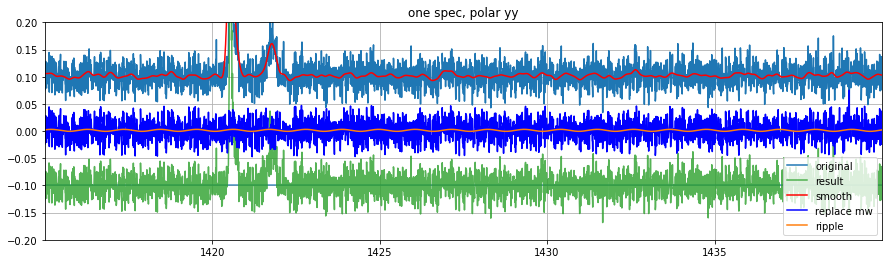

In [26]:
%matplotlib inline
tn = 4500
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.1],freq[0],freq[-1],alpha = .8)
ax.plot(freq,data[tn]+.1,label='original')
ax.plot(freq,rmsw_data[tn] -.1,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) +.1,'r',label = 'smooth')
ax.plot(freq,data_rep[tn],'b',label='replace mw')
ax.plot(freq,sw_data[tn],c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-.2,.2) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar yy')

平均10条谱线效果更明显，std降低了很多

Text(0.5, 1.0, 'ten specs mean, polar yy')

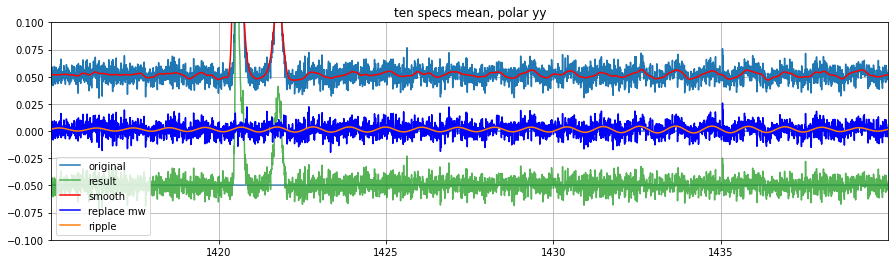

In [27]:
%matplotlib inline
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.05],freq[0],freq[-1],alpha = .8)
ax.plot(freq,np.mean(data[tn-5:tn+5],axis=0)+.05,label='original')
ax.plot(freq,np.mean(rmsw_data[tn-5:tn+5],axis=0) -.05,label='result',c='C2',alpha = .8)
ax.plot(freq,np.mean(smooth1d(data[tn-5:tn+5],method='gaussian', sigma=10),axis=0) +.05,'r',label = 'smooth')
ax.plot(freq,np.mean(data_rep[tn-5:tn+5],axis=0),'b',label='replace mw')
ax.plot(freq,np.mean(sw_data[tn-5:tn+5],axis=0),c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-.1,.1) 
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar yy')

瀑布图效果

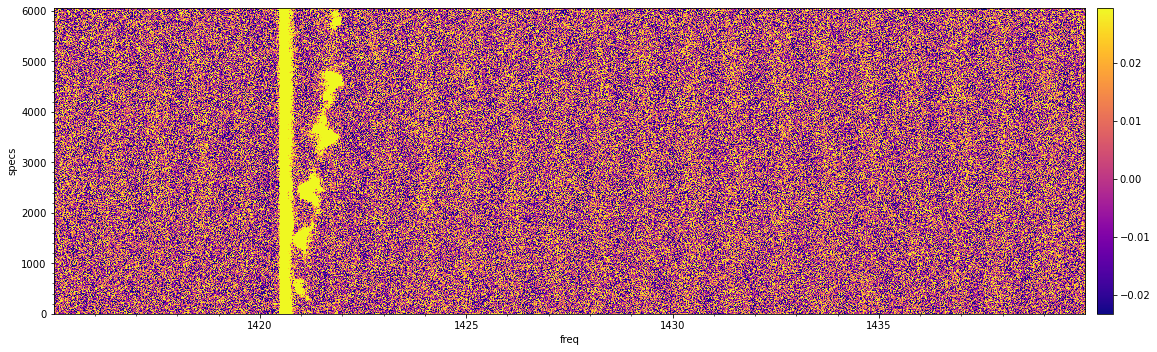

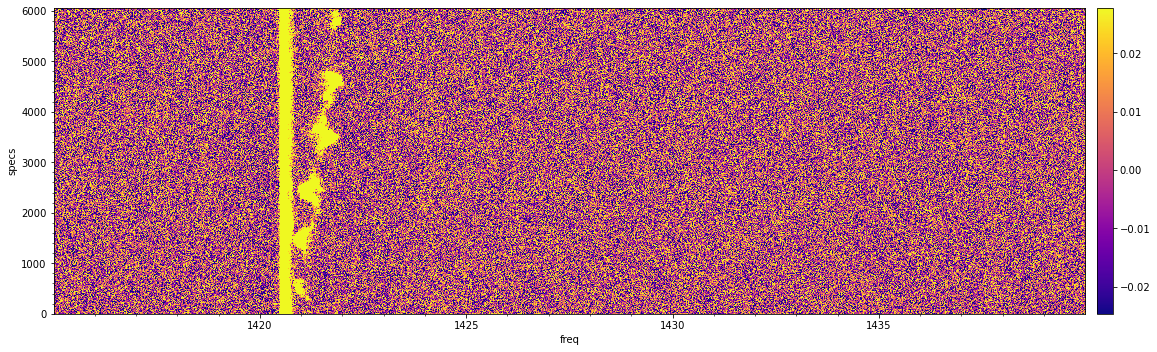

In [28]:
plot_waterfall(subs,data = data,per_vmin_max=.8,cmap='plasma',figsize=(18,5))
plot_waterfall(subs,data = rmsw_data,per_vmin_max=.8,cmap='plasma',figsize=(18,5))

如果我们最后比较一下两种替代银河系方法。。。

In [29]:
%matplotlib inline
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1425,1435]
rep_args['times_lower_thr'] = 4
rep_args['rfi_width_lim'] = 10
rep_args['ext_sec'] = 2
rep_args['ext_freq'] = 1.3

In [30]:
data_rep1 = replace_rfi(data,freq,time_rfi =is_rfi, method='near_ripple',mw_frange= mw_frange, **rep_args)

INFO: Replace RFI with near_ripple method ... [hifast.ripple.sw_fft]


In [31]:
sw_data1 = fit_sw_fft(data_rep1, freq, nproc=10,  **fft_args)

/home/xuc/.local/lib/python3.9/site-packages/hifast/ripple/sw_fft.py:316: RuntimeWarning: divide by zero encountered in true_divide
  self.period = 1/self.x


find ripple 1.08702 MHz,0.91994 mu s,locate in 23
find ripple 0.54351 MHz,1.83989 mu s,locate in 46


In [32]:
rmsw_data1 = data - sw_data1

Text(0.5, 1.0, 'ten specs, polar yy')

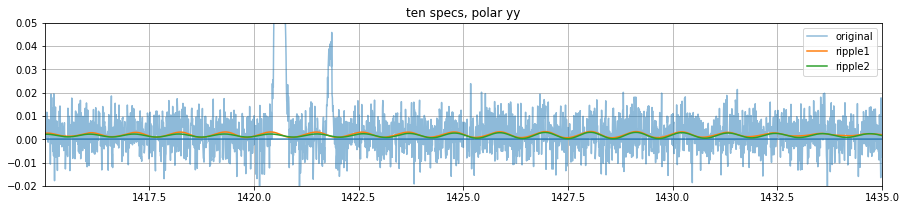

In [33]:
%matplotlib inline
tn = 6000
fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(111)
ax.hlines([0,],freq[0],freq[-1],alpha = .8)
ax.plot(freq,np.mean(data[tn-5:tn+5],axis = 0),alpha=.5,label='original')
ax.plot(freq,np.mean(sw_data1[tn-5:tn+5],axis = 0),c= 'C1',label='ripple1')
ax.plot(freq,np.mean(sw_data[tn-5:tn+5],axis = 0),c= 'C2',label='ripple2')
ax.set_xlim(freq[0],1435)
ax.set_ylim(-.02,.05) 
ax.grid();ax.legend();ax.set_title(f'ten specs, polar yy')

星系附近的驻波振幅相位会有一点差别

使用配置文件跑一下，这里未使用默认的`mw_frange`

In [34]:
!python -m hifast.sw $rfiname -c ./S4-sw.ini -f

###################################Args###################################
Command Line Args:   /data/inspur_disk01/userdir/jyj/FAST/jingyj/hifast/example_1/process/data_S/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-flux-bld-rfi.hdf5 -c ./S4-sw.ini -f
Config File (./S4-sw.ini):
  outdir:            ./data
  frange:            ['0', 'inf']
  nproc:             10
  method:            fft
  nobld:             False
  s_method_t:        none
  s_sigma_t:         5
  s_method_freq:     none
  s_sigma_freq:      5
  average_every_freq:0
  njoin:             10
  exclude_m:         0
  sin_f:             0.929
  deg:               1
  rfi_method:        near_ripple
  rms_sigma:         6
  rms_frange:        [1425, 1435]
  times_lower_thr:   2.5
  ext_freq:          1.3
  rfi_width_lim:     10
  ext_sec:           2
  sw_base:           True
  sw_periods:        ['1mhz', '2mhz', '0_04mhz']
  check_2mhz:        True
  amp_thr_mean_factor:1.05
  amp_thr_solo_factor:1.4
  chan_wide:         3

In [35]:
fs = h5py.File('./data/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-flux-bld-rfi-sw.hdf5','r')['S']
fdata = fs['flux'][1,:,:] 

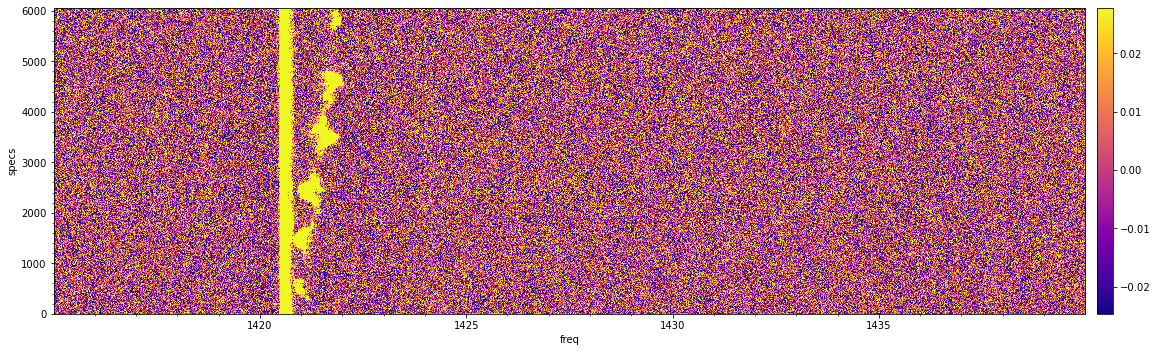

In [36]:
plot_waterfall(fs,data = fdata,per_vmin_max=.8,cmap='plasma',figsize=(18,5))

嗯，确实去除了驻波。